In [17]:
from pathlib import Path
import os

script_dir = globals().get("script_dir", Path.cwd().parent if Path.cwd().name == "out" else Path.cwd())
fig_dir = script_dir / "fig"
out_dir = script_dir / "out"
fig_dir.mkdir(exist_ok=True)
out_dir.mkdir(exist_ok=True)
os.chdir(out_dir)


参考
https://mpb.readthedocs.io/en/latest/Python_Data_Analysis_Tutorial/

In [18]:
import math
import meep as mp
from meep import mpb

import numpy as np
import matplotlib.pyplot as plt


In [19]:
#屈折率
n_air = 1
n_si = 2.6

#計算する固有周波数の数
num_bands = 4

#メッシュの細かさ
resolution = 32

#Γ-K, K-M, M-Γ間の点の個数
num_of_kpoint = 10

#単位格子
geometry_lattice = mp.Lattice(size=mp.Vector3(1, 1),
                              basis1=mp.Vector3(1./2, np.sqrt(3)/2),
                              basis2=mp.Vector3(1./2, -np.sqrt(3)/2))

#構造
#default_material = mp.Medium(epsilon=n_si**2)
geometry = [
    mp.Block(material=mp.Medium(epsilon=n_si**2),
             size=mp.Vector3(mp.inf, mp.inf)),
    mp.Cylinder(0.25, material=mp.Medium(epsilon=n_air**2))
]

#ブリルアンゾーン
k_points = [
    mp.Vector3(),               # Gamma
    mp.Vector3(1./3, 1./3),    # K
    mp.Vector3(1./2, 0),          # M
    mp.Vector3(),               # Gamma
]
k_points = mp.interpolate(num_of_kpoint, k_points)

In [20]:
#計算
ms = mpb.ModeSolver(
    geometry=geometry,
    geometry_lattice=geometry_lattice,
    k_points=k_points,
    resolution=resolution,
    num_bands=num_bands
)

ms.run_tm(mpb.output_at_kpoint(mp.Vector3(1./3, 1./3),
                               mpb.fix_efield_phase,
                               mpb.output_efield_z))
tm_freqs = ms.all_freqs
tm_gaps = ms.gap_list
ms.run_te(mpb.output_at_kpoint(mp.Vector3(1./3, 1./3),
                               mpb.fix_efield_phase,
                               mpb.output_efield_z))
te_freqs = ms.all_freqs
te_gaps = ms.gap_list

Initializing eigensolver data
Computing 4 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 32 x 32 x 1.
Solving for 4 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (0.5, 0.866025, 0)
     (0.5, -0.866025, 0)
     (0, 0, 1)
Cell volume = 0.866025
Reciprocal lattice vectors (/ 2 pi):
     (1, 0.57735, -0)
     (1, -0.57735, 0)
     (-0, 0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1e+20,0)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
Geometric object tree has depth 1 and 10 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: tm.
Initializing fields to random numbers...
34 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.0303030303030303, 0.0303030303030303, 0.0>
  Vector3<0.0606060606060606, 0.0606060606060606, 0.0>
  Vector3<0.0909090909090909, 0.0909090909090909,

In [21]:
md = mpb.MPBData(rectify=True, periods=3, resolution=64)
eps = ms.get_epsilon()
converted_eps = md.convert(eps)
converted_eps.shape

epsilon: 1-6.76, mean 5.45406, harm. mean 3.06613, 80.957% > 1, 77.3275% "fill"
real part range: 1 .. 6.76


(192, 166)

In [22]:
import csv
with open(out_dir / 'epsilon_distribution.csv', 'wt') as f:
    writer = csv.writer(f)
    writer.writerows(converted_eps)

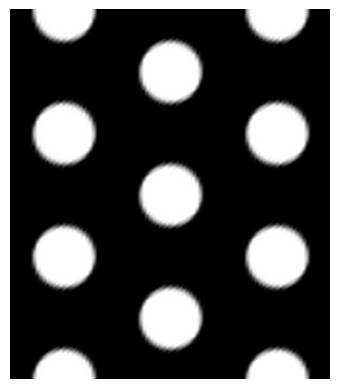

In [23]:
plt.imshow(converted_eps, interpolation='spline36', cmap="binary")
plt.axis('off')
plt.show()

In [24]:
tm_freqs.max()

np.float64(0.5501179168830966)

Initializing eigensolver data
Computing 4 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 32 x 32 x 1.
Solving for 4 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (0.5, 0.866025, 0)
     (0.5, -0.866025, 0)
     (0, 0, 1)
Cell volume = 0.866025
Reciprocal lattice vectors (/ 2 pi):
     (1, 0.57735, -0)
     (1, -0.57735, 0)
     (-0, 0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1e+20,0)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
Geometric object tree has depth 1 and 10 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Solving for band polarization: te.
Initializing fields to random numbers...
34 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.0303030303030303, 0.0303030303030303, 0.0>
  Vector3<0.0606060606060606, 0.0606060606060606, 0.0>
  Vector3<0.0909090909090909, 0.0909090909090909, 0.0>
  Vector3<0.121

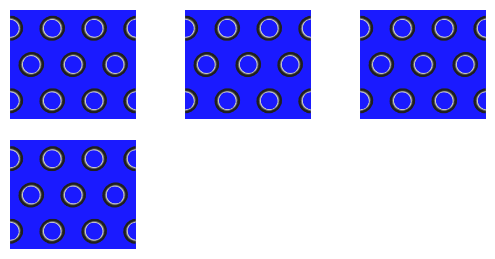

In [25]:
efields = []

def get_efields(ms, band):
    efields.append(ms.get_efield(band, bloch_phase=True))

ms.run_te(mpb.output_at_kpoint(mp.Vector3(1/3, 1/3), mpb.fix_efield_phase,
          get_efields))

# Create an MPBData instance to transform the efields
md = mpb.MPBData(rectify=True, resolution=64, periods=3)

converted = []
for f in efields:
    # Get just the z component of the efields
    f = f[..., 0, 2]
    converted.append(md.convert(f))

for i, f in enumerate(converted):
    plt.subplot(331 + i)
    plt.contour(converted_eps.T, cmap='binary')
    plt.imshow(np.real(f).T, interpolation='spline36', cmap='bwr', alpha=0.9)
    plt.axis('off')

plt.show()

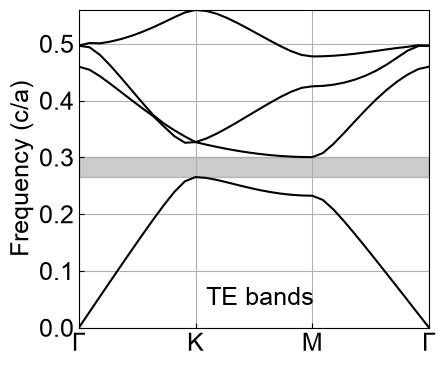

In [26]:
fs = 18
plt.rcParams.update({
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'font.size': fs,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
})
fig, ax = plt.subplots(figsize=(4.8, 4))

x = range(len(te_freqs))

#ax.plot(tm_freqs, color='gray')
ax.plot(te_freqs, color='black')
ax.set_ylim([te_freqs.min(), te_freqs.max()])
ax.set_xlim([x[0], x[-1]])

# Plot gaps
for gap in te_gaps:
    if gap[0] > 1:
        ax.fill_between(x, gap[1], gap[2], color='black', alpha=0.2)

# Plot labels
ax.text(12, 0.04, 'TE bands', color='black', size=fs)
#ax.text(13.05, 0.235, 'TE bands', color='red', size=15)

points_in_between = (len(te_freqs) - 4) / 3
tick_locs = [i*points_in_between+i for i in range(4)]
tick_labs = ['Γ', 'K', 'M', 'Γ']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=fs)
ax.set_ylabel('Frequency (c/a)', size=fs)
plt.tick_params(labelsize=fs)
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / "2d_hole_cir.svg", bbox_inches="tight")
plt.show()